In [89]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from pathlib import Path

In [90]:
figures = Path.cwd().parent / "figures"
figures.mkdir(parents=True, exist_ok=True)

In [91]:
df = pd.read_csv("train.csv")

In [92]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [93]:
class_count = df["Transported"].value_counts()
class_percentage = df["Transported"].value_counts(normalize=True) * 100

balance = pd.DataFrame({
    "Quantidade": class_count,
    "Percentual": class_percentage
})

balance

,Quantidade,Percentual
Transported,,
True,4378,50.362361
False,4315,49.637639


In [94]:
numeric_features = [
    "Age",
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

categorical_features = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "VIP"
]

id_features = [
    "PassangerId",
    "Name"
]


Valores Faltantes

In [95]:
missing_values = pd.DataFrame({
    "Quantity": df.isna().sum(),
    "Percentual": df.isna().mean() * 100
})

missing_values

,Quantity,Percentual
PassengerId,0,0.000000
HomePlanet,201,2.312205
CryoSleep,217,2.496261
Cabin,199,2.289198
Destination,182,2.093639
Age,179,2.059128
VIP,203,2.335212
RoomService,181,2.082135
FoodCourt,183,2.105142
ShoppingMall,208,2.392730


In [96]:
missing_values[missing_values["Quantity"] > 0]

,Quantity,Percentual
HomePlanet,201,2.312205
CryoSleep,217,2.496261
Cabin,199,2.289198
Destination,182,2.093639
Age,179,2.059128
VIP,203,2.335212
RoomService,181,2.082135
FoodCourt,183,2.105142
ShoppingMall,208,2.392730
Spa,183,2.105142


In [97]:
df.isna().mean() * 100

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64

Gastos

In [98]:
spending_columns = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

spending_statistics = df[spending_columns].agg([
    "mean",
    "median",
    "max"
]).T

spending_statistics

,mean,median,max
RoomService,224.687617,0.0,14327.0
FoodCourt,458.077203,0.0,29813.0
ShoppingMall,173.729169,0.0,23492.0
Spa,311.138778,0.0,22408.0
VRDeck,304.854791,0.0,24133.0


Todas as colunas de gasto apresentam mediana igual a zero, indicando que pelo menos metade dos passageiros não realizou gastos nesses serviços. Entretanto, as médias são positivas e variam aproximadamente entre 174 e 458, pois uma pequena quantidade de passageiros possui gastos muito elevados, com máximos entre 14 mil e 30 mil. Essa grande diferença entre média e mediana indica distribuições bastante espalhadas e assimétricas à direita: há uma forte concentração de valores em zero e uma cauda longa formada por poucos gastos extremos.

B

In [99]:
X = df.drop(columns="Transported")
Y = df["Transported"]

In [100]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, train_size=0.8, stratify=Y, random_state=42)

In [101]:
print("Treino:", x_train.shape)
print("Teste:", x_test.shape)

print("\nProporção no treino:")
print(y_train.value_counts(normalize=True))

print("\nProporção no teste:")
print(y_test.value_counts(normalize=True))

Treino: (6954, 13)
Teste: (1739, 13)

Proporção no treino:
Transported
True     0.503595
False    0.496405
Name: proportion, dtype: float64

Proporção no teste:
Transported
True     0.503738
False    0.496262
Name: proportion, dtype: float64


A separação deve acontecer antes da imputação e do escalonamento para que as estatísticas utilizadas nessas transformações sejam calculadas apenas com os dados de treino. Caso a mediana, a média ou o desvio-padrão sejam calculados usando também o conjunto de teste, informações do teste influenciam a preparação do modelo, causando vazamento de dados. Isso produz uma avaliação excessivamente otimista e menos confiável.

C

In [102]:
columns_to_drop = ["Cabin", "Name", "PassengerId"]

x_train = x_train.drop(columns=columns_to_drop).copy()
x_test = x_test.drop(columns=columns_to_drop).copy()

In [103]:
numeric_columns = [
    "Age",
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

categorical_columns = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "VIP"
]

spending_columns = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

In [104]:
numeric_imputer = SimpleImputer(strategy="median")

x_train[numeric_columns] = numeric_imputer.fit_transform(
    x_train[numeric_columns]
)

x_test[numeric_columns] = numeric_imputer.transform(
    x_test[numeric_columns]
)

In [105]:
categorical_imputer = SimpleImputer(strategy="most_frequent")

x_train[categorical_columns] = categorical_imputer.fit_transform(
    x_train[categorical_columns]
)

x_test[categorical_columns] = categorical_imputer.transform(
    x_test[categorical_columns]
)

Nas features numéricas, os valores faltantes foram preenchidos com a mediana, pois ela é menos sensível aos valores extremos presentes nas colunas de gasto. Nas features categóricas, foi utilizada a categoria mais frequente, mantendo os valores dentro das categorias já existentes. Os imputadores foram ajustados somente no treino e aplicados ao teste para evitar vazamento de dados.

In [106]:
x_train["TotalSpend"] = x_train[spending_columns].sum(axis=1)
x_test["TotalSpend"] = x_test[spending_columns].sum(axis=1)

In [107]:
room_service_before = x_train["RoomService"].copy()

In [108]:
x_train[spending_columns] = np.log1p(
    x_train[spending_columns]
)

x_test[spending_columns] = np.log1p(
    x_test[spending_columns]
)

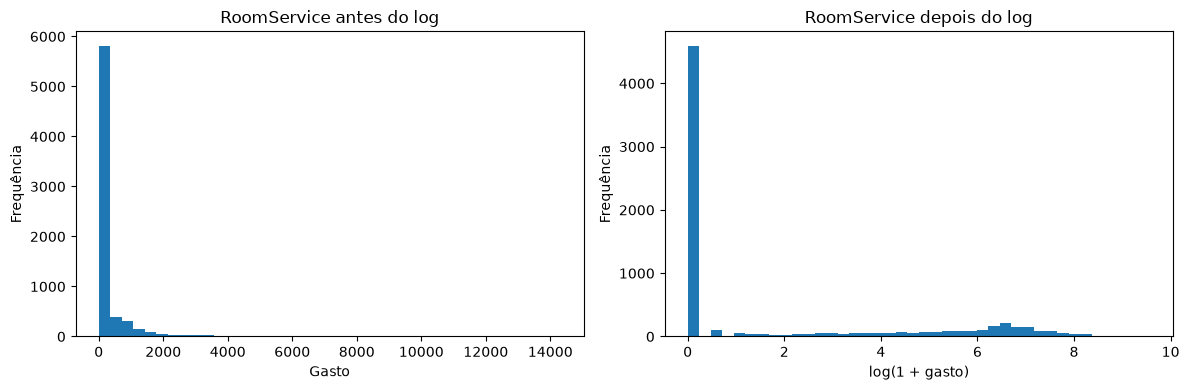

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(room_service_before, bins=40)
axes[0].set_title("RoomService antes do log")
axes[0].set_xlabel("Gasto")
axes[0].set_ylabel("Frequência")

axes[1].hist(x_train["RoomService"], bins=40)
axes[1].set_title("RoomService depois do log")
axes[1].set_xlabel("log(1 + gasto)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.savefig(figures / 'RoomService_before_after_log.png',  dpi=300, bbox_inches='tight')
plt.show()

A transformação logarítmica reduz a diferença entre os gastos comuns e os valores extremamente altos, deixando a distribuição menos assimétrica. Isso evita entradas exageradamente grandes, que poderiam levar a `tanh` para suas regiões saturadas, onde ela aprende mais lentamente.

Conversao categoria -> numero

In [110]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

train_categorical = encoder.fit_transform(
    x_train[categorical_columns]
)

test_categorical = encoder.transform(
    x_test[categorical_columns]
)

Padronizar numericas

In [111]:
final_numeric_columns = numeric_columns + ["TotalSpend"]

In [112]:
scaler = StandardScaler()

train_numeric = scaler.fit_transform(
    x_train[final_numeric_columns]
)

test_numeric = scaler.transform(
    x_test[final_numeric_columns]
)

In [113]:
print(f"Treino — mínimo: {train_numeric.min():.4f}")
print(f"Treino — máximo: {train_numeric.max():.4f}")

print(f"Teste — mínimo: {test_numeric.min():.4f}")
print(f"Teste — máximo: {test_numeric.max():.4f}")

Treino — mínimo: -1.9961
Treino — máximo: 12.5430
Teste — mínimo: -1.9961
Teste — máximo: 9.6711


Foi utilizada a padronização com StandardScaler, que transforma as features para que apresentem média próxima de zero e desvio-padrão próximo de um. Essa transformação reduz diferenças de escala entre as features e concentra grande parte dos valores na região central da tanh, onde seus gradientes são maiores. Após a transformação, os valores variaram de [mínimo] a [máximo] no treino e de [mínimo] a [máximo] no teste.

Juntando numericas e categoricas

In [114]:
X_train_processed = np.hstack([
    train_numeric,
    train_categorical
])

X_test_processed = np.hstack([
    test_numeric,
    test_categorical
])

In [115]:
print(X_train_processed.shape)
print(X_test_processed.shape)

print("Valores faltantes no treino:",
      np.isnan(X_train_processed).sum())

print("Valores faltantes no teste:",
      np.isnan(X_test_processed).sum())

(6954, 17)
(1739, 17)
Valores faltantes no treino: 0
Valores faltantes no teste: 0


D

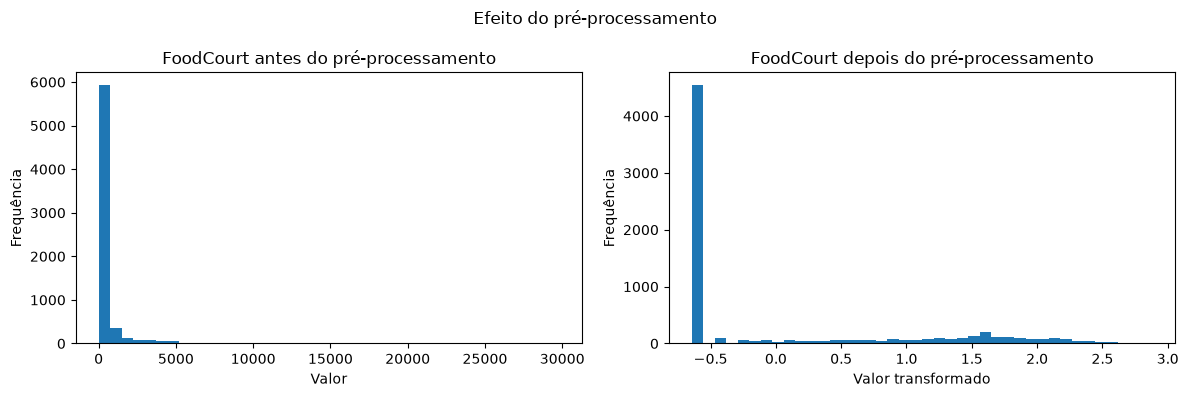

In [116]:
foodcourt_before = df.loc[x_train.index, "FoodCourt"].dropna()

foodcourt_index = final_numeric_columns.index("FoodCourt")
foodcourt_after = train_numeric[:, foodcourt_index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(foodcourt_before, bins=40)
axes[0].set_title("FoodCourt antes do pré-processamento")
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Frequência")

axes[1].hist(foodcourt_after, bins=40)
axes[1].set_title("FoodCourt depois do pré-processamento")
axes[1].set_xlabel("Valor transformado")
axes[1].set_ylabel("Frequência")

fig.suptitle("Efeito do pré-processamento")
plt.tight_layout()
plt.savefig(figures / 'pre_processing_effect.png',  dpi=300, bbox_inches='tight')
plt.show()

In [117]:
print("NaNs no treino:", np.isnan(X_train_processed).sum())
print("NaNs no teste:", np.isnan(X_test_processed).sum())

print("Shape do treino:", X_train_processed.shape)
print("Shape do teste:", X_test_processed.shape)

print(
    f"Intervalo no treino: "
    f"[{X_train_processed.min():.4f}, "
    f"{X_train_processed.max():.4f}]"
)

print(
    f"Intervalo no teste: "
    f"[{X_test_processed.min():.4f}, "
    f"{X_test_processed.max():.4f}]"
)

NaNs no treino: 0
NaNs no teste: 0
Shape do treino: (6954, 17)
Shape do teste: (1739, 17)
Intervalo no treino: [-1.9961, 12.5430]
Intervalo no teste: [-1.9961, 9.6711]


As decisões com maior impacto no treinamento são a transformação logarítmica e a padronização das features numéricas. O log reduz a influência dos gastos extremamente altos e torna suas distribuições menos assimétricas, enquanto a padronização impede que features de maior escala dominem as demais. Essas transformações concentram os valores em uma faixa mais adequada para a tanh, reduzindo sua saturação e facilitando o aprendizado da rede.

In [118]:
minimum = X_train_processed.min()
maximum = X_train_processed.max()

print(f"Faixa das features: [{minimum:.4f}, {maximum:.4f}]")

Faixa das features: [-1.9961, 12.5430]
